In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
import functools
from math import pi

import numpy as np
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.plotting.collision_heatmap import bin2d_maximum, make_colorbar, mycmap
from fluxoniumcr.qubits.fluxonium import Fluxonium


plt.style.use("fluxoniumcr.plotting.paper")

In [3]:
q0 = Fluxonium(
    EJ=4.0 * (2*pi),
    EC=1.2 * (2*pi),
    EL=0.4 * (2*pi),
    flux=0.5,
    cutoff=128,
    dim=4,
)

q0_evals = q0.eigenvalues

In [4]:
parent_path = (
    DATA_DIR
    /"control_target_collision"
    / f"EJ=4.00,EC=1.20,EL=0.40,deltap=1.0"
)
dataset1 = xr.load_dataset(parent_path/"01to12_harmonic=-4.hdf5")
dataset2 = xr.load_dataset(parent_path/"11to02_harmonic=-4.hdf5")

parent_path_08 = (
    DATA_DIR
    /"control_target_collision"
    / f"EJ=4.00,EC=1.20,EL=0.40,deltap=0.8"
)
dataset3 = xr.load_dataset(parent_path_08/"11to02_harmonic=-2.hdf5")

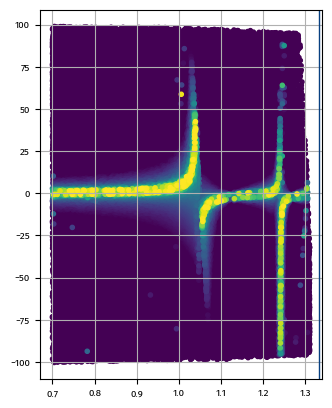

In [5]:
dataset = dataset1
ds = dataset.isel(JC=0)
leakage = ds.transition_probability.sel(target_bra=2).sum('control_bra').mean(['control_ket', 'target_ket'])

idx = np.argsort(leakage)

# idx = mask

plt.scatter(
    dataset.drive_frequency.sel(index=idx)/(2*pi),
    dataset.delta_frequency.sel(index=idx) * 1e3/(2*pi),
    c=np.log10(leakage.sel(index=idx)).data,
    vmin=-5,
    vmax=-1,
    s=9,
)

plt.grid()
# plt.xlim(-50, 50)
# plt.ylim(0.9, 1.5)
# plt.xlim(-15, 15)
# plt.ylim(0.7, 1.3)

plt.gca().set_aspect(1/250)

plt.axvline(1.332)

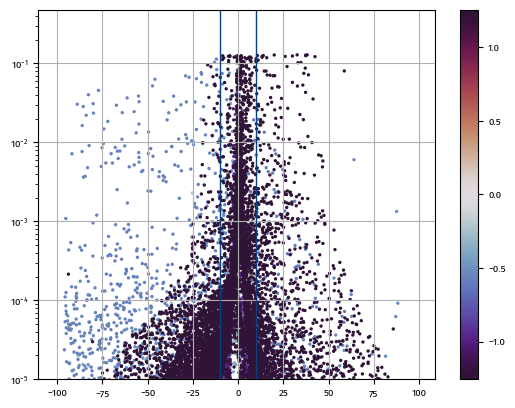

In [6]:
fig, ax = plt.subplots()


dataset = dataset1
ds = dataset.isel(JC=0)
leakage = ds.transition_probability.sel(target_bra=2).sum('control_bra').mean(['control_ket', 'target_ket'])

z = ds.drive_frequency - 1.332*2*pi
idx = np.argsort(abs(z))
z = z.sel(index=idx)

s = ax.scatter(
    ds.delta_frequency.sel(index=idx) / (2*pi) * 1e3,
    leakage.sel(index=idx),
    s=2,
    c=z,
    cmap='twilight_shifted',
    vmin=-0.2 * 2*pi,
    vmax=0.2 * 2*pi,
)
ax.set_yscale('log')
ax.set_ylim(1e-5)
plt.colorbar(s)

plt.axvline(-10)
plt.axvline(+10)

plt.grid()

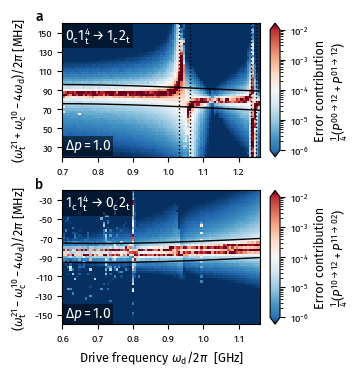

In [8]:
fig = plt.figure(
    figsize=(85/25.4, 90/25.4),
)

gs = GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[100, 5],
    hspace=0.25,
    wspace=0.1,
)

ax1 = fig.add_subplot(gs[0, 0])
cax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0])
cax2 = fig.add_subplot(gs[1, 1])

hm1_x = np.linspace(0.6, 1.4, 128) * 2*pi
hm1_y = (0.09 + np.linspace(-80e-3, 80e-3, 64)) * 2*pi

hm2_x = np.linspace(0.5, 1.3, 128) * 2*pi
hm2_y = (-0.09 + np.linspace(-80e-3, 80e-3, 64)) * 2*pi

z1 = 1/4 * sum(
    dataset1.isel(JC=0).transition_probability.sel(
        control_bra=1,
        control_ket=0,
        target_bra=2,
        target_ket=i,
    )
    for i in range(2)
).data

z2 = 1/4 * sum(
    dataset2.isel(JC=0).transition_probability.sel(
        control_bra=0,
        control_ket=1,
        target_bra=2,
        target_ket=i,
    )
    for i in range(2)
).data

bare_delta1 = (
    dataset1.isel(JC=0).transition_frequency
    + q0_evals[1] - q0_evals[0]
    - 4*dataset1.drive_frequency
).data

bare_delta2 = (
    dataset2.isel(JC=0).transition_frequency
    + q0_evals[0] - q0_evals[1]
    - 4*dataset2.drive_frequency
).data

hm1 = bin2d_maximum(
    dataset1.drive_frequency.data,
    bare_delta1,
    z1,
    hm1_x,
    hm1_y,
)

hm2 = bin2d_maximum(
    dataset2.drive_frequency.data,
    bare_delta2,
    z2,
    hm2_x,
    hm2_y,
)

norm = mpl.colors.LogNorm(vmin=1e-6/5, vmax=5e-2)
    
mesh1 = ax1.pcolormesh(
    hm1_x,
    hm1_y,
    hm1,
    rasterized=True,
    cmap=mycmap,
    norm=norm,
)

mesh2 = ax2.pcolormesh(
    hm2_x,
    hm2_y,
    hm2,
    rasterized=True,
    cmap=mycmap,
    norm=norm,
)

for cax, label in zip([cax1, cax2], [
        "Error contribution\n"r"$\frac{1}{4}(P^{00\to12} + P^{01\to12})$",
        "Error contribution\n"r"$\frac{1}{4}(P^{10\to12} + P^{11\to02})$",
]):
    make_colorbar(
        cax,
        norm=norm,
        cmap=mycmap,
        vmin=1e-6,
        vmax=1e-2,
        yticks=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
        label=label,
    )

# cax1.set_yticks([1e-6, 1e-4, 1e-2])
# cax2.set_yticks([1e-6, 1e-4, 1e-2])
# cax2.set_yticks([1e-8, 1e-6, 1e-4])
ax1.set_ylim((90e-3 - 70e-3) * 2*pi, (90e-3 + 70e-3) * 2*pi)
ax2.set_ylim((-90e-3 - 70e-3) * 2*pi, (-90e-3 + 70e-3) * 2*pi)
ax1.set_yticks((90 + np.array([-60, -40, -20, 0.0, 20, 40, 60])) * 1e-3 *2*pi)
ax2.set_yticks((-90 + np.array([-60, -40, -20, 0.0, 20, 40, 60])) * 1e-3 *2*pi)

for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(lambda x, pos: f"{x/(2*pi):.1f}")
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x*1e3/(2*pi):.0f}")
    
ax2.set_xlim(0.6 * 2*pi, 1.2 * 2*pi)


for ax in [ax2]:
    ax.set_xlabel(r"Drive frequency $\omega_\mathrm{d}/2\pi$  [GHz]")

ax1.set_ylabel(
    r"$(\omega_\mathrm{t}^{21} + \omega_\mathrm{c}^{10} - 4\omega_\mathrm{d})/2\pi$" + " [MHz]",
    labelpad=6.8,
)
ax2.set_ylabel(r"$(\omega_\mathrm{t}^{21} - \omega_\mathrm{c}^{10} - 4\omega_\mathrm{d})/2\pi$" + " [MHz]")


c = 'black'
ax1.axvline(1.032 * (2*pi), ls=':', c=c)
ax1.axvline(1.061 * (2*pi), ls=':', c=c)
ax1.axvline(1.235 * (2*pi), ls=':', c=c)
ax1.axvline(1.248 * (2*pi), ls=':', c=c)
# ax2.axvline(0.800 * (2*pi), ls=':', c=c)
# ax2.axvline(0.803 * (2*pi), ls=':', c=c)

for ax, label in [(ax1, "a"), (ax2, "b")]:
    annotation = ax.annotate(
        label,
        (0.00, 1.00),
#         (-26, 10),
        (-14, 10),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="right",
        va="top",
        zorder=1,
    )

for ax, num in [(ax1, 1), (ax2, 1)]:
    annotation = ax.annotate(
        r"$\Delta p=" + f"{num:.1f}$",
        (0.00, 0.00),
        (1.8, 1.8),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="left",
        va="bottom",
        c='white',
        zorder=2,
        bbox=dict(boxstyle='square,pad=0.15', fc='black', ec='none', alpha=0.5),
    )

for ax, label in [
        (ax1, r"$0_\mathrm{c}1_\mathrm{t}^4\to1_\mathrm{c}2_\mathrm{t}$"),
        (ax2, r"$1_\mathrm{c}1_\mathrm{t}^4\to0_\mathrm{c}2_\mathrm{t}$"),
]:
    annotation = ax.annotate(
        label,
        (0.00, 1.00),
        (1.8, -1.8),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="left",
        va="top",
        c='white',
        zorder=2,
        bbox=dict(boxstyle='square,pad=0.15', fc='black', ec='none', alpha=0.5),
    )

fig.subplots_adjust(
    left=0.15,
    right=0.80,
    bottom=0.11,
    top=0.96,
)

ax1.set_xlim(0.7 * 2*pi, 1.26 * 2*pi)
ax1.set_xticks(np.array([0.7, 0.8, 0.9, 1.0, 1.1, 1.2]) * 2*pi)
ax2.set_xlim(0.6 * 2*pi, 1.16 * 2*pi)
ax2.set_xticks(np.array([0.6, 0.7, 0.8, 0.9, 1.0, 1.1]) * 2*pi)

# Slice by ::200 to reduce the number of points to plot
idx = np.argsort(dataset1.drive_frequency)[::200]
x = dataset1.drive_frequency.data[idx]
y = (bare_delta1 - dataset1.delta_frequency.data)[idx]
# ax1.plot(x, y, c='deeppink')
i1 = np.searchsorted(x, (1.070 - 60e-3)*2*pi)
x = np.insert(x, i1, x[i1])
y = np.insert(y, i1, y[i1])
i2 = np.searchsorted(x, (1.070 - 0e-3)*2*pi)
x = np.insert(x, i2, x[i2])
y = np.insert(y, i2, y[i2])

offset = np.full(len(y), 10e-3 * 2*pi)
# offset[i1+1:i2+1] = 50e-3 * 2*pi

ax1.plot(x, y + offset, c='black')
ax1.plot(x, y - offset, c='black')

idx = np.argsort(dataset2.drive_frequency)[::200]
x = dataset2.drive_frequency.data[idx]
y = (bare_delta2 - dataset2.delta_frequency.data)[idx]
# ax2.plot(x, y, c='deeppink')
ax2.plot(x, y + 10e-3 * 2*pi, c='black')
ax2.plot(x, y - 10e-3 * 2*pi, c='black')
fig.savefig("control_target_fourth_harmonic.pdf")

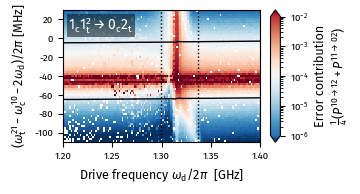

In [9]:
fig = plt.figure(
    figsize=(85/25.4, 40/25.4),
)

gs = GridSpec(
    nrows=1,
    ncols=2,
    figure=fig,
    width_ratios=[100, 5],
    wspace=0.1,
)

ax3 = fig.add_subplot(gs[0, 0])
cax3 = fig.add_subplot(gs[0, 1])

hm3_x = np.linspace(1.2, 1.4, 128) * 2*pi
hm3_y = (-0.04 + np.linspace(-70e-3, 70e-3, 64)) * 2*pi

z3 = 1/4 * sum(
    dataset3.isel(JC=0).transition_probability.sel(
        control_bra=0,
        control_ket=1,
        target_bra=2,
        target_ket=i,
    )
    for i in range(2)
).data

bare_delta3 = (
    dataset3.isel(JC=0).transition_frequency
    + q0_evals[0] - q0_evals[1]
    - 2*dataset3.drive_frequency
).data

hm3 = bin2d_maximum(
    dataset3.drive_frequency.data,
    bare_delta3,
    z3,
    hm3_x,
    hm3_y,
)

norm = mpl.colors.LogNorm(vmin=1e-6/5, vmax=5e-2)
    
mesh3 = ax3.pcolormesh(
    hm3_x,
    hm3_y,
    hm3,
    rasterized=True,
    cmap=mycmap,
    norm=norm,
)

for cax, label in zip([cax3], [
        "Error contribution\n"r"$\frac{1}{4}(P^{10\to12} + P^{11\to02})$",
]):
    make_colorbar(
        cax,
        norm=norm,
        cmap=mycmap,
        vmin=1e-6,
        vmax=1e-2,
        yticks=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
        label=label,
    )

ax3.set_ylim((-40e-3 - 70e-3) * 2*pi, (-40e-3 + 70e-3) * 2*pi)
ax3.set_yticks((-40 + np.array([-60, -40, -20, 0.0, 20, 40, 60])) * 1e-3 *2*pi)

for ax in [ax3]:
    ax.xaxis.set_major_formatter(lambda x, pos: f"{x/(2*pi):.2f}")
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x*1e3/(2*pi):.0f}")

for ax in [ax3]:
    ax.set_xlabel(r"Drive frequency $\omega_\mathrm{d}/2\pi$  [GHz]")

ax3.set_ylabel(r"$(\omega_\mathrm{t}^{21} - \omega_\mathrm{c}^{10} - 2\omega_\mathrm{d})/2\pi$" + " [MHz]")


c = 'black'
ax3.axvline(1.299 * (2*pi), ls=':', c=c)
ax3.axvline(1.337 * (2*pi), ls=':', c=c)


for ax, label in [
        (ax3, r"$1_\mathrm{c}1_\mathrm{t}^2\to0_\mathrm{c}2_\mathrm{t}$"),
]:
    annotation = ax.annotate(
        label,
        (0.00, 1.00),
        (4, -4),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="left",
        va="top",
        c='white',
        zorder=2,
        bbox=dict(boxstyle='square,pad=0.1', fc='black', ec='none', alpha=0.5),
    )

fig.subplots_adjust(
    left=0.15,
    right=0.80,
    bottom=0.12,
    top=0.96,
)

ax3.set_xlim(1.2 * 2*pi, 1.4 * 2*pi)
ax3.set_xticks(np.array([1.20, 1.25, 1.3, 1.35, 1.4]) * 2*pi)

# Slice by ::200 to reduce the number of points to plot
idx = np.argsort(dataset3.drive_frequency)[::200]
x = dataset3.drive_frequency.data[idx]
y = (bare_delta3 - dataset3.delta_frequency.data)[idx]

offset = np.full(len(y), 10e-3 * 2*pi)

ax3.plot(x, y + 40e-3 * 2*pi, c='black')
ax3.plot(x, y - 20e-3 * 2*pi, c='black')

fig.savefig("control_target_second_harmonic.pdf")